# ✈ Check-in Delay Predictor ✈

### Core Idea

-  In a tracking team, if a crew member checks in late for their briefing, it causes a cascading delay for the whole flight. This project builds a simple Python tool that looks at morning traffic, crew transit distances, and weather to predict how many minutes late a crew member might be.

### Generate the Dataset

We are generating 300 crew check-in records, connecting transit distances and weather directly to check-in delays.

In [3]:
import pandas as pd
import numpy as np

# Set seed for identical results
np.random.seed(42)
num_records = 300

# 1. Create realistic tracking data
# Distance from crew home/hotel to airport (in kilometers)
transit_distance_km = np.random.uniform(5.0, 45.0, size=num_records)

# Is it a morning rush-hour flight? (1 = Yes, 0 = No)
is_rush_hour = np.random.choice([0, 1], size=num_records, p=[0.6, 0.4])

# Weather condition score (1 = Perfect, 5 = Heavy Rain/Flood)
weather_score = np.random.randint(1, 6, size=num_records)

# 2. Calculate the Delay Minutes (The Target)
# Longer distance + rush hour + bad weather = higher check-in delay
base_delay = (transit_distance_km * 0.5) + (is_rush_hour * 15) + (weather_score * 4)
# Add some random real-world noise (traffic accidents, oversleeping, etc.)
random_noise = np.random.normal(0, 5, size=num_records)

arrival_delay_mins = base_delay + random_noise
# If the math results in a negative number, set delay to 0 (meaning they arrived on time)
arrival_delay_mins = np.clip(arrival_delay_mins, a_min=0, a_max=None)

# 3. Build and Save the DataFrame
df_checkin = pd.DataFrame({
    'crew_id': [f"CRW_{2000 + i}" for i in range(num_records)],
    'distance_km': np.round(transit_distance_km, 1),
    'rush_hour_flight': is_rush_hour,
    'weather_severity': weather_score,
    'delay_minutes': np.round(arrival_delay_mins, 1)
})

df_checkin.to_csv("crew_checkin_delays.csv", index=False)
print("✅ Check-in dataset saved as 'crew_checkin_delays.csv'")
print(df_checkin.head())

✅ Check-in dataset saved as 'crew_checkin_delays.csv'
    crew_id  distance_km  rush_hour_flight  weather_severity  delay_minutes
0  CRW_2000         20.0                 0                 5           41.4
1  CRW_2001         43.0                 0                 2           21.4
2  CRW_2002         34.3                 0                 4           33.7
3  CRW_2003         28.9                 1                 2           43.1
4  CRW_2004         11.2                 1                 5           37.7


### Analyze the Data (The "Why")

Let's examine the correlation matrix to understand the relationships between `distance_km`, `rush_hour_flight`, `weather_severity`, and the target variable `delay_minutes`.

In [4]:
# Calculate and display the correlation matrix
correlation_matrix = df_checkin.corr(numeric_only=True)
print(correlation_matrix)

                  distance_km  rush_hour_flight  weather_severity  \
distance_km          1.000000         -0.081979         -0.092796   
rush_hour_flight    -0.081979          1.000000          0.098857   
weather_severity    -0.092796          0.098857          1.000000   
delay_minutes        0.429461          0.614248          0.482827   

                  delay_minutes  
distance_km            0.429461  
rush_hour_flight       0.614248  
weather_severity       0.482827  
delay_minutes          1.000000  


### The Machine Learning Model (Linear Regression)

We will use Linear Regression for its simplicity and interpretability, making it ideal for predicting exact numbers like delay minutes. First, we'll split the data into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X) and target (y)
X = df_checkin[['distance_km', 'rush_hour_flight', 'weather_severity']]
y = df_checkin['delay_minutes']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Data split into training and testing sets successfully.
Training set size: 240 samples
Testing set size: 60 samples


In [6]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Linear Regression model trained successfully.
Model Coefficients: [ 0.53968002 14.96775958  3.85139505]
Model Intercept: -0.2945333056321111


### Test and Predict

Let's use our trained model to predict the delay for a new, hypothetical scenario: a crew member living 40km away, flying during rush hour, with a severe weather score of 5.

In [7]:
# Define the imaginary scenario
imaginary_scenario = pd.DataFrame({
    'distance_km': [40.0],
    'rush_hour_flight': [1],
    'weather_severity': [5]
})

# Predict the delay for the imaginary scenario
predicted_delay = model.predict(imaginary_scenario)

print(f"Predicted delay for the imaginary scenario: {predicted_delay[0]:.2f} minutes")

Predicted delay for the imaginary scenario: 55.52 minutes


### Evaluate Model Performance

To understand how well our model performs on unseen data, we'll calculate the Mean Absolute Error (MAE) on the test set. MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.

In [8]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE) on the test set: {mae:.2f} minutes")

Mean Absolute Error (MAE) on the test set: 3.78 minutes


Next, let's calculate the R-squared score to further evaluate the model's fit.

In [10]:
r_squared = model.score(X_test, y_test)
print(f"R-squared score on the test set: {r_squared:.2f}")

R-squared score on the test set: 0.83


After that, we will summarize the impact of each feature on the delay predictions based on the trained model's coefficients.

/tmp/ipykernel_1602/2128971855.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Influence', y='Feature', data=feature_importance_df, palette='viridis')


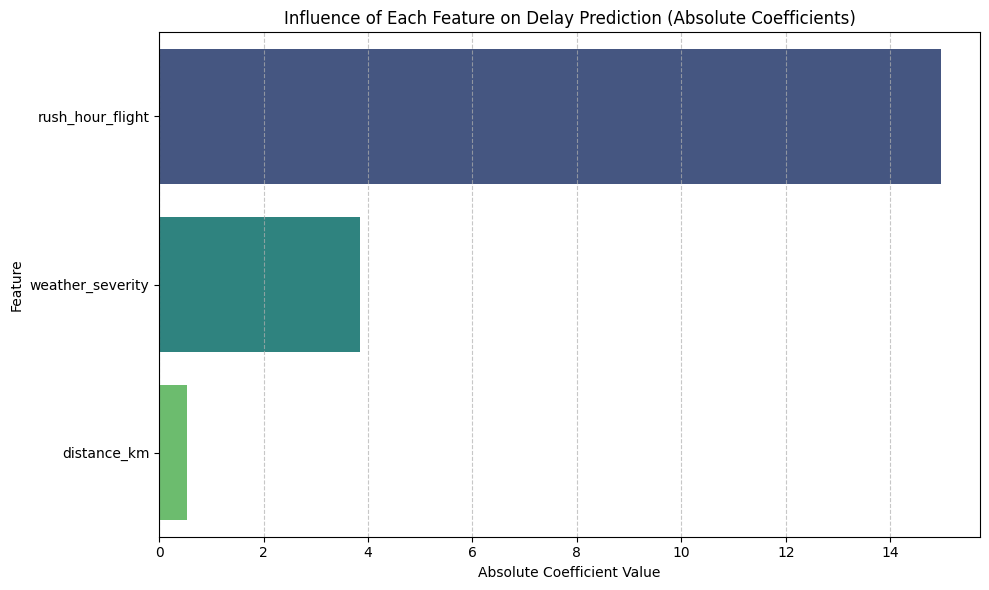

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the training data
feature_names = X_train.columns

# Get the absolute coefficients to show magnitude of influence
coefficients = np.abs(model.coef_)

# Create a DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Influence': coefficients
}).sort_values(by='Influence', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Influence', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Influence of Each Feature on Delay Prediction (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualize Actual vs. Predicted Delays

To further understand the model's performance, let's visualize the actual `delay_minutes` from the test set against the `predicted_delay` values. A scatter plot can help us see how closely the predictions align with the actual values.

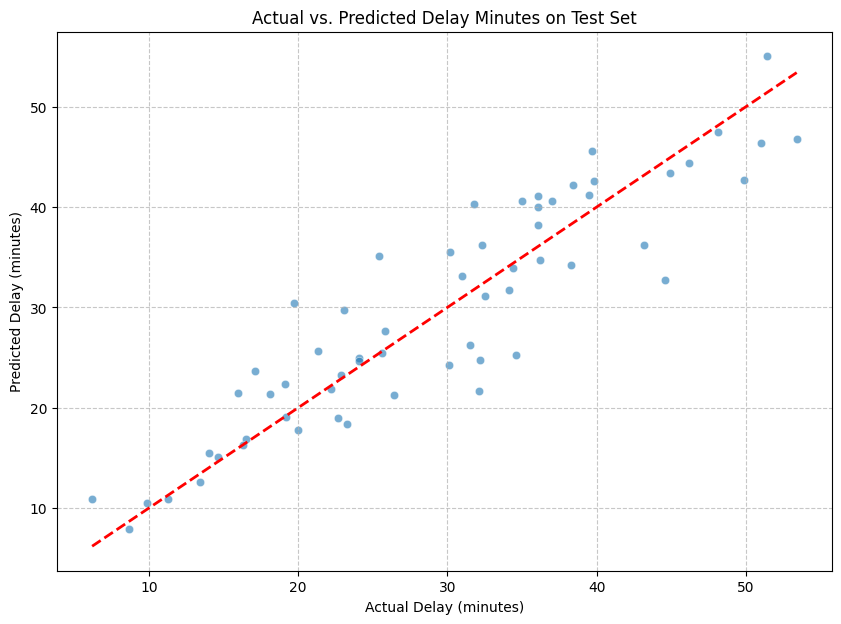

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Delay (minutes)')
plt.ylabel('Predicted Delay (minutes)')
plt.title('Actual vs. Predicted Delay Minutes on Test Set')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

We can observe that most of the points are clustered fairly close to the red dashed line, which indicates that our model is making reasonably accurate predictions. The spread of points around the line gives a visual representation of the model's error, which aligns with the Mean Absolute Error of 3.78 minutes we calculated earlier.